In [1]:
import os
import sys

ROOT_PATH = '../'
os.chdir(ROOT_PATH)

sys.path.append(os.path.abspath(ROOT_PATH))

lib_path = os.path.abspath(os.path.join(ROOT_PATH, 'lib'))
if lib_path not in sys.path:
  sys.path.append(lib_path)

In [2]:
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import pandas as pd
import huggingface_hub

In [3]:
load_dotenv()

True

In [4]:
huggingface_hub.snapshot_download(
  repo_id=os.environ.get('HF_MODEL_REPO_ID'),
  local_dir="./eval_results/",         # Where files will save
  token=os.environ.get('HF_TOKEN')       # Optional if already logged in
)

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

'E:\\dev\\Pre-Thesis\\vision-ai-development\\ai\\eval_results'

In [5]:
EVAL_RESULTS_DIR = './eval_results/eval_results'

vanilla_loss_history = pd.read_csv(f'{EVAL_RESULTS_DIR}/vanilla_loss_history.csv')
additional_both_loss_history = pd.read_csv(f'{EVAL_RESULTS_DIR}/additional-both_loss_history.csv')
additional_depth_loss_history = pd.read_csv(f'{EVAL_RESULTS_DIR}/additional-depth_loss_history.csv')
additional_normal_loss_history = pd.read_csv(f'{EVAL_RESULTS_DIR}/additional-normal_loss_history.csv')

In [6]:
additional_both_loss_history.head()

,epoch,train_loss,train_seg_loss,train_weighted_seg_loss,train_depth_loss,train_weighted_depth_loss,train_normal_loss,train_weighted_normal_loss,val_loss,val_seg_loss,val_weighted_seg_loss,val_depth_loss,val_weighted_depth_loss,val_normal_loss,val_weighted_normal_loss
0,1,19.481690,4.882554,2.793277,0.015574,0.994530,40.261240,15.693883,10.395722,4.620741,2.693911,0.006157,0.979768,15.796786,6.722043
1,2,15.812352,2.404552,1.885239,0.011151,0.959259,33.668457,12.967854,9.581154,4.493993,2.651970,0.006613,0.934992,14.206203,5.994192
2,3,14.501582,2.029113,1.743639,0.010416,0.902927,31.873245,11.855015,9.386191,5.171014,2.926216,0.006609,0.867620,13.640303,5.592355
3,4,13.510580,1.866994,1.671727,0.009496,0.824085,31.177989,11.014768,10.355556,7.030950,3.717818,0.006032,0.777546,15.332511,5.860192
4,5,12.547582,1.765258,1.613766,0.009727,0.723380,30.826131,10.210436,10.039479,7.597104,4.100479,0.006231,0.665481,14.358612,5.273520


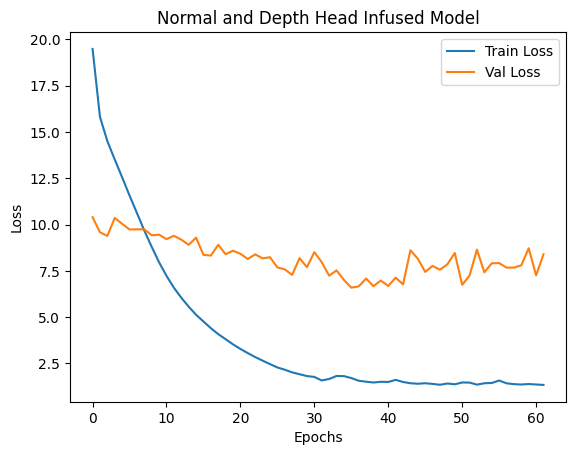

In [7]:

train_loss = additional_both_loss_history['train_loss']
val_loss = additional_both_loss_history['val_loss']

plt.title('Normal and Depth Head Infused Model')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.legend()

plt.show()